In [1]:
import os
import numpy as np
import json
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [2]:
X_PCA_PATH = "/kaggle/input/gene-preprocess/saved_model/X_pca.npy"

OUTPUT_DIR = "/kaggle/working/"
OUTPUT_DIR_MODEL = os.path.join(OUTPUT_DIR, "spectral_results")
os.makedirs(OUTPUT_DIR_MODEL, exist_ok=True)

OUTPUT_DIR_ENSEMBLE = os.path.join(OUTPUT_DIR, "spectral_ensemble")
os.makedirs(OUTPUT_DIR_ENSEMBLE, exist_ok=True)

In [3]:
X_pca = np.load(X_PCA_PATH)
print("X_pca shape:", X_pca.shape)

X_pca shape: (111, 10)


In [4]:
k_range = range(2, 20)

results = {
    'k': [],
    'silhouette': [],
    'labels': []
}

for k in k_range:
    spectral_clustering = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=10
    )
    
    labels = spectral_clustering.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    
    results['k'].append(k)
    results['silhouette'].append(score)
    results['labels'].append(labels)
    
    print(f"k={k} | silhouette={score}")

k=2 | silhouette=0.12929830927901306
k=3 | silhouette=0.19981497551176847
k=4 | silhouette=0.22195517970323442
k=5 | silhouette=0.18287530950440925
k=6 | silhouette=0.163887375520732
k=7 | silhouette=0.1430799288431396
k=8 | silhouette=0.1464513358737786
k=9 | silhouette=0.15811583059933682
k=10 | silhouette=0.19134396348605373
k=11 | silhouette=0.22553742173001207
k=12 | silhouette=0.21664698068741195
k=13 | silhouette=0.21902857697805614
k=14 | silhouette=0.21791773817706508
k=15 | silhouette=0.21771146456380724
k=16 | silhouette=0.20552638623882907
k=17 | silhouette=0.2008770355736984
k=18 | silhouette=0.1944079215622066
k=19 | silhouette=0.1983326008083396


In [5]:
df_results = pd.DataFrame(results)
df_results.head()

,k,silhouette,labels
0,2,0.129298,"[0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, ..."
1,3,0.199815,"[1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 2, 1, 2, 1, 0, ..."
2,4,0.221955,"[1, 2, 0, 2, 3, 3, 0, 0, 0, 2, 0, 1, 0, 1, 2, ..."
3,5,0.182875,"[4, 0, 3, 2, 1, 1, 3, 3, 3, 2, 0, 0, 3, 0, 2, ..."
4,6,0.163887,"[3, 5, 0, 1, 2, 2, 4, 4, 0, 1, 0, 5, 4, 5, 1, ..."


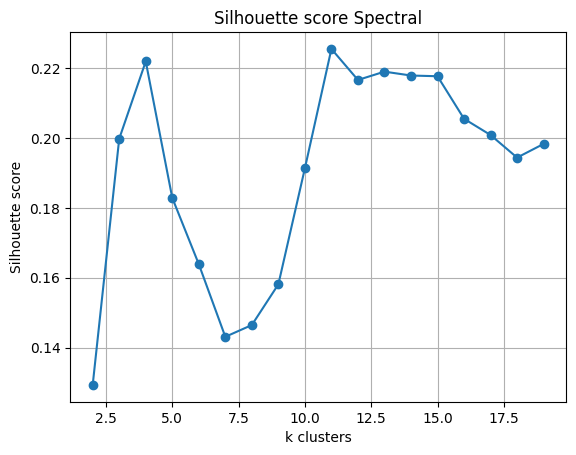

In [6]:
plt.plot(df_results["k"], df_results["silhouette"], marker="o")
plt.xlabel("k clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette score Spectral")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR_MODEL, "spectral_silhouette.png"))
plt.show()

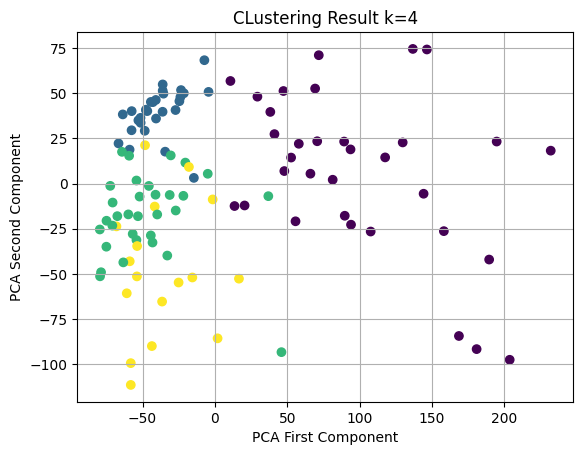

In [7]:
k = 4
row_index = k-2
df_label = df_results['labels'][row_index]

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_label)
plt.xlabel("PCA First Component")
plt.ylabel("PCA Second Component")
plt.title(f"CLustering Result k={k}")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR_MODEL, "spectral_clustering.png"))
plt.show()

In [8]:
k = 20
n_runs = 5
n_compares = n_runs*2

all_labels = []

In [9]:
for i in range(n_runs):
    spectral_clustering = SpectralClustering(
        n_clusters=5,
        affinity="nearest_neighbors",
        n_neighbors=10,
    )
    all_labels.append(spectral_clustering.fit_predict(X_pca))

In [10]:
ari_scores = []

for _ in range(n_compares):
    i, j = random.sample(range(n_runs), 2)
    ari = adjusted_rand_score(all_labels[i], all_labels[j])
    ari_scores.append(ari)

ari_scores = np.array(ari_scores)
print(f"ARI mean: {ari_scores.mean()}")

ARI mean: 0.9797619091385672


In [11]:
spectral_clustering = SpectralClustering(
    n_clusters=5,
    affinity="nearest_neighbors",
    n_neighbors=10
)
labels = spectral_clustering.fit_predict(X_pca)

In [12]:
path = os.path.join(OUTPUT_DIR_MODEL, "spectral_all_results.csv")
df_results.to_csv(path, index=False)

path = os.path.join(OUTPUT_DIR_MODEL, "spectral_config.json")
config = {
    'k': 4,
    'affinity': "nearest_neighbors",
    'n_neighbors': 10
}
with open(path, "w") as f:
    json.dump(config, f)

path = os.path.join(OUTPUT_DIR_MODEL, "spectral_labels.npy")
np.save(path, df_results['labels'][row_index])

In [13]:
path = os.path.join(OUTPUT_DIR_ENSEMBLE, "spectral_ensemble_labels.npy")
np.save(path, labels)

path = os.path.join(OUTPUT_DIR_ENSEMBLE, "spectral_ensemble_config.npy")
config = {
    'k': 5,
    'affinity': "nearest_neighbors",
    'n_neighbors': 10
}
with open(path, "w") as f:
    json.dump(config, f)